# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


**Dataset yang digunakan: Wine Quality (Red)**

- **Sumber**: UCI Machine Learning Repository
- **URL**: https://archive.ics.uci.edu/ml/datasets/wine+quality
- **Jumlah Data**: 1599 baris, 12 kolom
- **Tipe**: Tabular/Structured Data
- **Fitur**: 11 fitur fisikokimia (fixed acidity, volatile acidity, citric acid, dll.)
- **Target**: `quality` (skor 3-8, dikonversi menjadi klasifikasi biner: 0=Bad, 1=Good)
- **Referensi**: P. Cortez et al., 2009

Dataset ini dipilih karena cocok untuk eksperimen machine learning lifecycle (preprocessing, modeling, monitoring).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load dataset dari file lokal
raw_path = os.path.join('..', 'wine_quality_raw', 'winequality-red.csv')

if os.path.exists(raw_path):
    df = pd.read_csv(raw_path, sep=';')
    print(f'Dataset loaded from: {raw_path}')
else:
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    df = pd.read_csv(url, sep=';')
    print(f'Dataset downloaded from UCI repository')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded from: ..\wine_quality_raw\winequality-red.csv
Shape: (1599, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
# Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

=== Missing Values ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing: 0


In [6]:
# Cek duplikat
duplicates = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates}')
print(f'Persentase duplikat: {duplicates/len(df)*100:.2f}%')

Jumlah data duplikat: 240
Persentase duplikat: 15.01%


=== Distribusi Quality ===
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


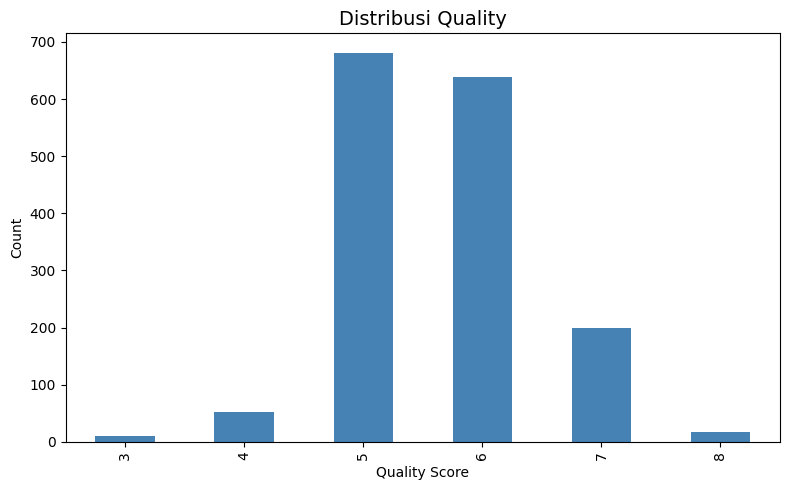

In [7]:
# Distribusi target (quality)
print('=== Distribusi Quality ===')
print(df['quality'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Distribusi Quality', fontsize=14)
ax.set_xlabel('Quality Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

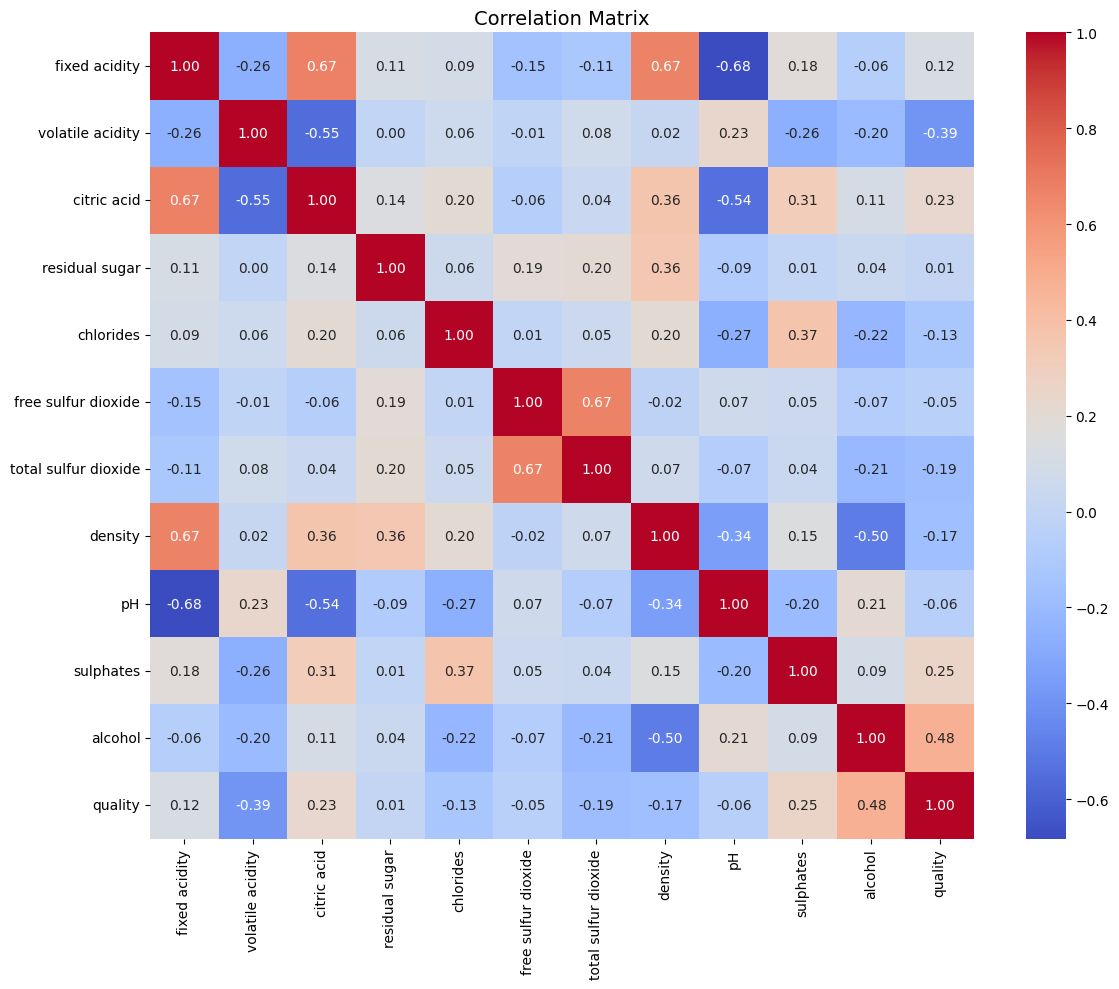

In [8]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

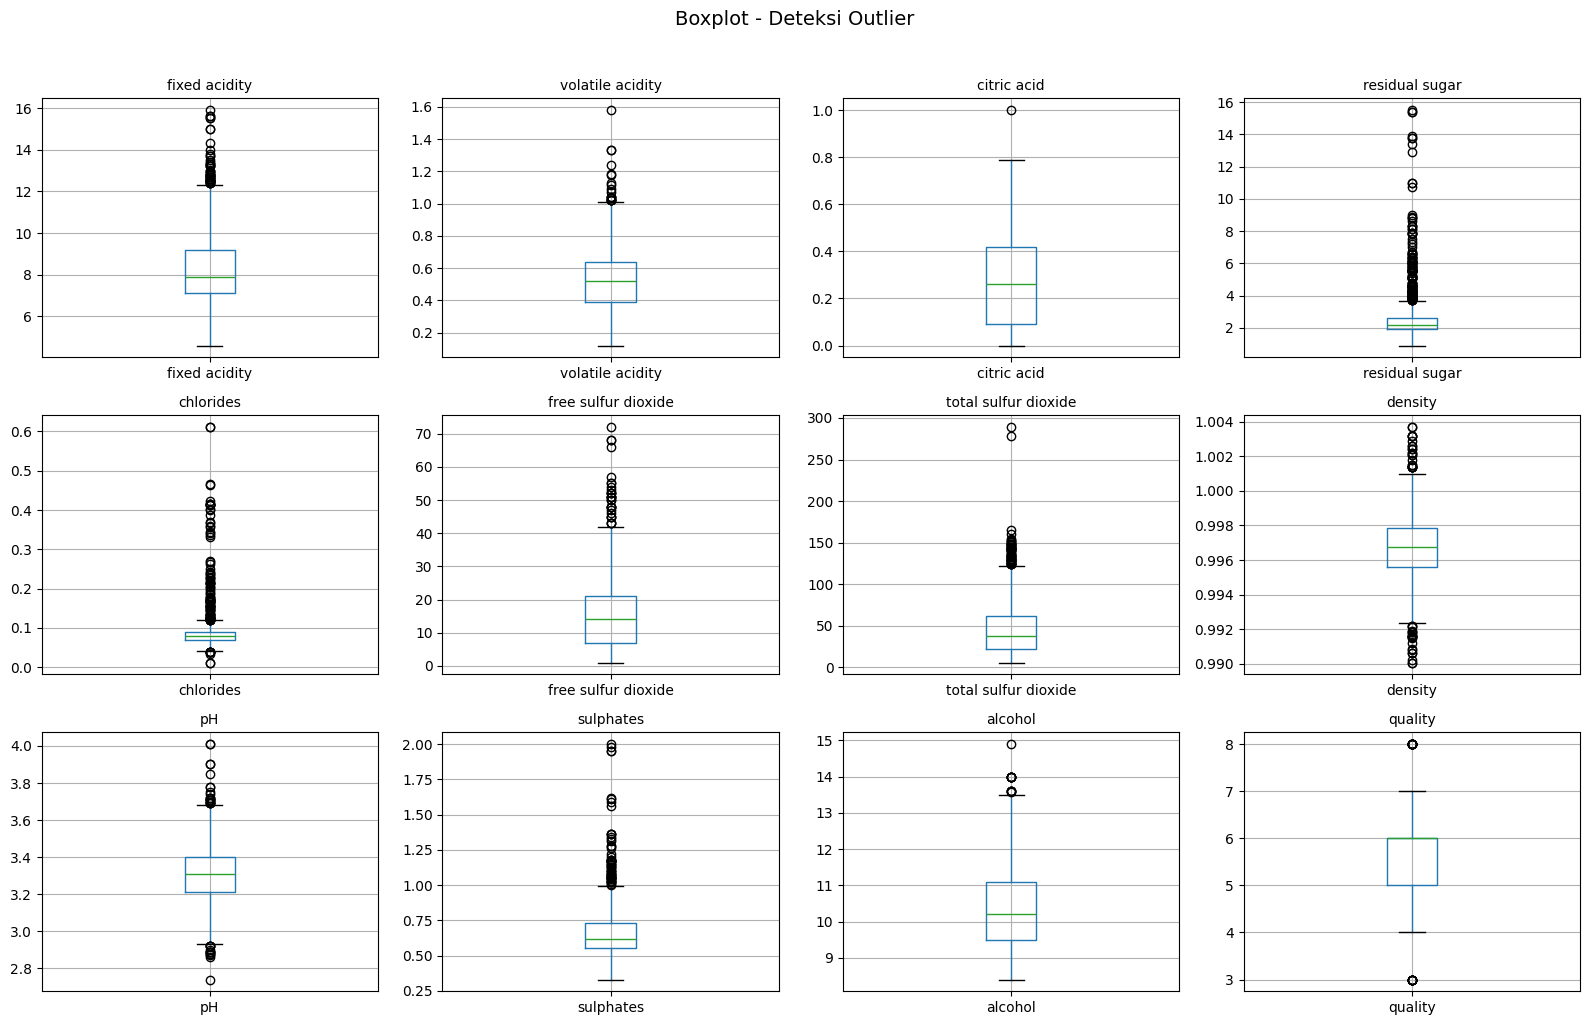

In [9]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(df.columns):
    ax = axes[i // 4, i % 4]
    df.boxplot(column=col, ax=ax)
    ax.set_title(col, fontsize=10)
plt.suptitle('Boxplot - Deteksi Outlier', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
# ============================================================
# STEP 1: Handle Missing Values
# ============================================================
print('=== Step 1: Handle Missing Values ===')
print(f'Missing values sebelum: {df.isnull().sum().sum()}')

# Fill numeric columns with median
df_processed = df.copy()
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f'  Filled {col} with median: {median_val}')

print(f'Missing values sesudah: {df_processed.isnull().sum().sum()}')

=== Step 1: Handle Missing Values ===
Missing values sebelum: 0
Missing values sesudah: 0


In [11]:
# ============================================================
# STEP 2: Remove Duplicates
# ============================================================
print('=== Step 2: Remove Duplicates ===')
print(f'Jumlah sebelum: {len(df_processed)}')
df_processed = df_processed.drop_duplicates()
print(f'Jumlah sesudah: {len(df_processed)}')
print(f'Duplikat dihapus: {len(df) - len(df_processed)}')

=== Step 2: Remove Duplicates ===
Jumlah sebelum: 1599
Jumlah sesudah: 1359
Duplikat dihapus: 240


In [12]:
# ============================================================
# STEP 3: Binning - Create Binary Target
# ============================================================
print('=== Step 3: Binning - Binary Classification ===')
df_processed['quality_label'] = (df_processed['quality'] > 5).astype(int)
print(f'  Bad  (quality <= 5): {(df_processed["quality_label"] == 0).sum()}')
print(f'  Good (quality >  5): {(df_processed["quality_label"] == 1).sum()}')

=== Step 3: Binning - Binary Classification ===
  Bad  (quality <= 5): 640
  Good (quality >  5): 719


In [13]:
# ============================================================
# STEP 4: Feature/Target Separation + Train/Test Split
# ============================================================
print('=== Step 4: Train/Test Split ===')
feature_cols = [col for col in df_processed.columns if col not in ['quality', 'quality_label']]
X = df_processed[feature_cols]
y = df_processed['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

=== Step 4: Train/Test Split ===
Train: 1087 samples
Test:  272 samples


In [14]:
# ============================================================
# STEP 5: Normalisasi / Standarisasi Fitur
# ============================================================
print('=== Step 5: StandardScaler ===')
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)
print('StandardScaler applied!')
print(f'Mean (train): {X_train_scaled.mean().mean():.6f}')
print(f'Std  (train): {X_train_scaled.std().mean():.6f}')

=== Step 5: StandardScaler ===
StandardScaler applied!
Mean (train): 0.000000
Std  (train): 1.000460


In [15]:
# ============================================================
# STEP 6: Save Preprocessed Data
# ============================================================
print('=== Step 6: Save Preprocessed Data ===')
output_dir = 'wine_quality_preprocessing'
os.makedirs(output_dir, exist_ok=True)

train_df = X_train_scaled.copy()
train_df['quality_label'] = y_train
test_df = X_test_scaled.copy()
test_df['quality_label'] = y_test

train_df.to_csv(os.path.join(output_dir, 'train.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test.csv'), index=False)

full_df = pd.concat([train_df, test_df])
full_df.to_csv(os.path.join(output_dir, 'wine_quality_preprocessed.csv'), index=False)

print(f'Train saved: {train_df.shape}')
print(f'Test saved: {test_df.shape}')
print(f'Full saved: {full_df.shape}')
print('\nPreprocessing complete!')

=== Step 6: Save Preprocessed Data ===
Train saved: (1087, 12)
Test saved: (272, 12)
Full saved: (1359, 12)

Preprocessing complete!
